In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

rfm = pd.read_csv('data/processed/rfm_segments.csv')

print(f"Table RFM chargée : {len(rfm):,} clients")
print()
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']].head()

Table RFM chargée : 4,338 clients



,CustomerID,Recency,Frequency,Monetary,Segment
0,12346,326,1,77183.60,Clients Ordinaires
1,12347,2,7,4310.00,Champions
2,12348,75,4,1797.24,Clients Endormis
3,12349,19,1,1757.55,Nouveaux Clients
4,12350,310,1,334.40,Clients Perdus


 Transformation logarithmique

In [ ]:
rfm['Recency_log']   = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log']  = np.log1p(rfm['Monetary'])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[0, i].hist(rfm[col].clip(upper=rfm[col].quantile(0.99)),
                    bins=50, color='#D9534F', edgecolor='white')
    axes[0, i].set_title(f'{col} — Avant log', fontweight='bold')

    axes[1, i].hist(rfm[f'{col}_log'], bins=50,
                    color='#2E75B6', edgecolor='white')
    axes[1, i].set_title(f'{col} — Après log', fontweight='bold')

plt.suptitle('Effet de la transformation logarithmique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/log_transformation.png', dpi=150, bbox_inches='tight')
plt.show()

 Standardisation

In [48]:
# K-Means est sensible aux échelles → on ramène tout entre 0 et 1
features = ['Recency_log', 'Frequency_log', 'Monetary_log']

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=features)

print("Données standardisées (moyenne=0, écart-type=1)")
print()
print(rfm_scaled.describe().round(3))

✅ Données standardisées (moyenne=0, écart-type=1)

       Recency_log  Frequency_log  Monetary_log
count     4338.000       4338.000      4338.000
mean        -0.000         -0.000        -0.000
std          1.000          1.000         1.000
min         -2.341         -0.955        -3.998
25%         -0.661         -0.955        -0.684
50%          0.090         -0.362        -0.065
75%          0.845          0.653         0.657
max          1.564          5.859         4.732


  K= 2 → Inertie : 6,484
  K= 3 → Inertie : 4,869
  K= 4 → Inertie : 3,939
  K= 5 → Inertie : 3,297
  K= 6 → Inertie : 2,856
  K= 7 → Inertie : 2,549
  K= 8 → Inertie : 2,336
  K= 9 → Inertie : 2,156
  K=10 → Inertie : 2,006
  K=11 → Inertie : 1,873
  K=12 → Inertie : 1,767


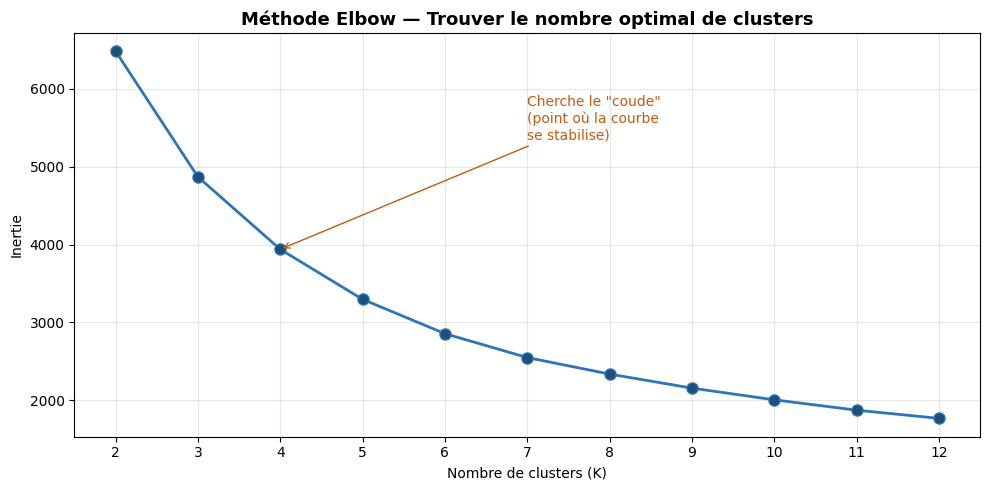

In [49]:
# On teste K de 2 à 12 et on mesure l'inertie (somme des distances)
inertias = []
k_range = range(2, 13)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    print(f"  K={k:2d} → Inertie : {kmeans.inertia_:,.0f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2,
         color='#2E75B6', markersize=8, markerfacecolor='#1F4E79')
plt.title('Méthode Elbow — Trouver le nombre optimal de clusters',
          fontsize=13, fontweight='bold')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.annotate('Cherche le "coude"\n(point où la courbe\nse stabilise)',
             xy=(4, inertias[2]), fontsize=10, color='#C55A11',
             arrowprops=dict(arrowstyle='->', color='#C55A11'),
             xytext=(7, inertias[2] + (inertias[0]-inertias[-1])*0.3))
plt.tight_layout()
plt.savefig('reports/figures/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

  K= 2 → Silhouette Score : 0.4328
  K= 3 → Silhouette Score : 0.3365
  K= 4 → Silhouette Score : 0.3375
  K= 5 → Silhouette Score : 0.3162
  K= 6 → Silhouette Score : 0.3124
  K= 7 → Silhouette Score : 0.3092
  K= 8 → Silhouette Score : 0.3033
  K= 9 → Silhouette Score : 0.2811
  K=10 → Silhouette Score : 0.2767
  K=11 → Silhouette Score : 0.2748
  K=12 → Silhouette Score : 0.2750


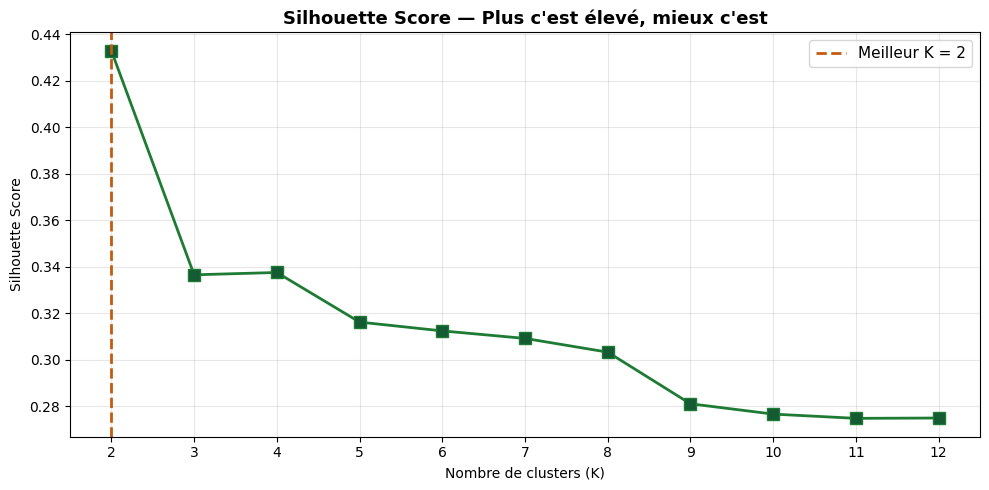


🏆 Meilleur K selon Silhouette Score : K = 2


In [50]:
# Silhouette Score mesure la qualité des clusters (plus proche de 1 = mieux)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"  K={k:2d} → Silhouette Score : {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='s', linewidth=2,
         color='#1E7B34', markersize=8, markerfacecolor='#145A32')
plt.title('Silhouette Score — Plus c\'est élevé, mieux c\'est',
          fontsize=13, fontweight='bold')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

best_k = k_range[np.argmax(silhouette_scores)]
plt.axvline(x=best_k, color='#C55A11', linestyle='--', linewidth=2,
            label=f'Meilleur K = {best_k}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('reports/figures/silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Meilleur K selon Silhouette Score : K = {best_k}")

In [51]:
# En général le bon K se situe entre 3 et 6 pour ce dataset
# Combine les deux méthodes pour décider

for i, k in enumerate(k_range):
    print(f"K={k:2d} | Inertie: {inertias[i]:8,.0f} | "
          f"Silhouette: {silhouette_scores[i]:.4f}"
          + (" ← MEILLEUR" if k == best_k else ""))

print()
print(f"💡 Recommendation : utilise K = {best_k}")
print("   (tu peux tester K±1 pour comparer les résultats)")

K_OPTIMAL = best_k  # on garde cette valeur pour la suite

📊 AIDE À LA DÉCISION
K= 2 | Inertie:    6,484 | Silhouette: 0.4328 ← MEILLEUR
K= 3 | Inertie:    4,869 | Silhouette: 0.3365
K= 4 | Inertie:    3,939 | Silhouette: 0.3375
K= 5 | Inertie:    3,297 | Silhouette: 0.3162
K= 6 | Inertie:    2,856 | Silhouette: 0.3124
K= 7 | Inertie:    2,549 | Silhouette: 0.3092
K= 8 | Inertie:    2,336 | Silhouette: 0.3033
K= 9 | Inertie:    2,156 | Silhouette: 0.2811
K=10 | Inertie:    2,006 | Silhouette: 0.2767
K=11 | Inertie:    1,873 | Silhouette: 0.2748
K=12 | Inertie:    1,767 | Silhouette: 0.2750

💡 Recommendation : utilise K = 2
   (tu peux tester K±1 pour comparer les résultats)


In [52]:
K_OPTIMAL = 4

In [53]:
kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

print(f"K-Means entraîné avec K = {K_OPTIMAL}")
print()
print("Répartition des clusters :")
print(rfm['Cluster'].value_counts().sort_index())

K-Means entraîné avec K = 4

Répartition des clusters :
Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


In [54]:
# Comprendre ce que représente chaque cluster
cluster_profile = rfm.groupby('Cluster').agg(
    Nb_Clients  = ('CustomerID',  'count'),
    Recency_moy = ('Recency',     'mean'),
    Freq_moy    = ('Frequency',   'mean'),
    Monetary_moy= ('Monetary',    'mean'),
).round(1)

cluster_profile['% Clients'] = (
    cluster_profile['Nb_Clients'] / len(rfm) * 100
).round(1)

print("PROFIL DE CHAQUE CLUSTER")
print(cluster_profile.to_string())

📋 PROFIL DE CHAQUE CLUSTER
         Nb_Clients  Recency_moy  Freq_moy  Monetary_moy  % Clients
Cluster                                                            
0               713         12.2      13.8        8088.0       16.4
1              1622        181.5       1.3         341.0       37.4
2               837         17.7       2.2         557.3       19.3
3              1166         71.6       4.1        1801.8       26.9


In [55]:
# Nommage basé sur les VRAIES valeurs du tableau
cluster_map = {
    0: '🥇 Champions',
    1: '❌ Clients Perdus',
    2: '🆕 Nouveaux Actifs',
    3: '💙 Clients Fidèles'
}

rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_map)

print("Clusters nommés :")
for k, v in cluster_map.items():
    row = cluster_profile.loc[k]
    print(f"   Cluster {k} → {v}")
    print(f"              Recency={row['Recency_moy']}j | "
          f"Freq={row['Freq_moy']} | "
          f"Monetary=£{row['Monetary_moy']:,.0f} | "
          f"{row['% Clients']}% des clients")
    print()

✅ Clusters nommés :
   Cluster 0 → 🥇 Champions
              Recency=12.2j | Freq=13.8 | Monetary=£8,088 | 16.4% des clients

   Cluster 1 → ❌ Clients Perdus
              Recency=181.5j | Freq=1.3 | Monetary=£341 | 37.4% des clients

   Cluster 2 → 🆕 Nouveaux Actifs
              Recency=17.7j | Freq=2.2 | Monetary=£557 | 19.3% des clients

   Cluster 3 → 💙 Clients Fidèles
              Recency=71.6j | Freq=4.1 | Monetary=£1,802 | 26.9% des clients



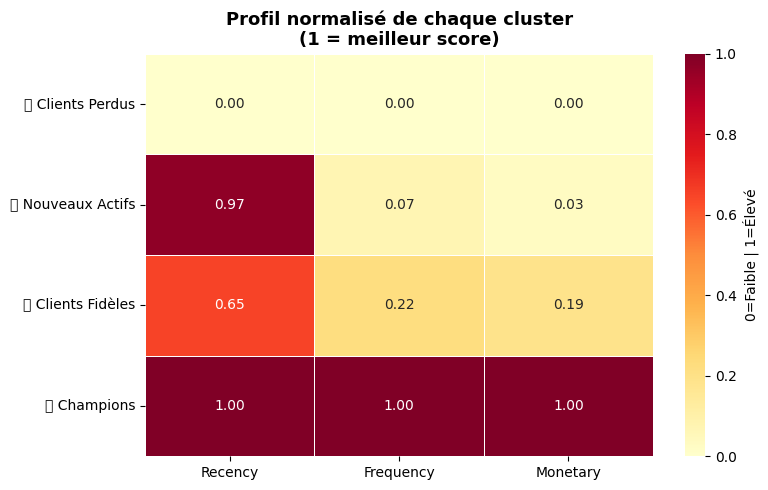

In [56]:
from sklearn.preprocessing import MinMaxScaler

heat_data = rfm.groupby('Cluster_Name')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

# Inverser Recency (moins de jours = meilleur client)
heat_data['Recency'] = heat_data['Recency'].max() - heat_data['Recency']

scaler_mm = MinMaxScaler()
heat_normalized = pd.DataFrame(
    scaler_mm.fit_transform(heat_data),
    columns=heat_data.columns,
    index=heat_data.index
)

plt.figure(figsize=(8, 5))
sns.heatmap(heat_normalized, annot=True, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': '0=Faible | 1=Élevé'})
plt.title('Profil normalisé de chaque cluster\n(1 = meilleur score)',
          fontsize=13, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('reports/figures/cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

visualisations 2D

In [57]:
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = rfm_pca[:, 0]
rfm['PCA2'] = rfm_pca[:, 1]

print(f" Variance expliquée par PCA : "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

fig = px.scatter(
    rfm, x='PCA1', y='PCA2',
    color='Cluster_Name',
    hover_data=['CustomerID', 'Recency', 'Frequency', 'Monetary'],
    title='Clusters clients — Visualisation 2D (PCA)',
    color_discrete_map={
        '🥇 Champions'     : '#1F4E79',
        '❌ Clients Perdus' : '#C55A11',
        '🆕 Nouveaux Actifs': '#1E7B34',
        '💙 Clients Fidèles': '#7030A0'
    },
    template='plotly_white', width=900, height=600
)
fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.write_html('reports/figures/clusters_pca_2d.html')
fig.show()

✅ Variance expliquée par PCA : 93.9%


visualisations 3D

In [58]:
fig_3d = px.scatter_3d(
    rfm,
    x='Recency', y='Frequency', z='Monetary',
    color='Cluster_Name',
    hover_data=['CustomerID'],
    title='Clusters clients — Vue 3D (R, F, M)',
    color_discrete_map={
        '🥇 Champions'     : '#1F4E79',
        '❌ Clients Perdus' : '#C55A11',
        '🆕 Nouveaux Actifs': '#1E7B34',
        '💙 Clients Fidèles': '#7030A0'
    },
    template='plotly_white', width=900, height=650,
    opacity=0.7
)
fig_3d.update_traces(marker=dict(size=3))
fig_3d.write_html('reports/figures/clusters_pca_3d.html')
fig_3d.show()

In [59]:
# On clippe les outliers extrêmes pour une meilleure visualisation
rfm_viz = rfm.copy()
rfm_viz['Monetary_viz']  = rfm_viz['Monetary'].clip(upper=10000)
rfm_viz['Frequency_viz'] = rfm_viz['Frequency'].clip(upper=30)

fig_3d = px.scatter_3d(
    rfm_viz,
    x='Recency',
    y='Frequency_viz',
    z='Monetary_viz',
    color='Cluster_Name',
    hover_data=['CustomerID', 'Recency', 'Frequency', 'Monetary'],
    title='Clusters clients — Vue 3D (R, F, M)',
    labels={
        'Recency'      : 'Recency (jours)',
        'Frequency_viz': 'Frequency (max affiché: 30)',
        'Monetary_viz' : 'Monetary £ (max affiché: 10k)'
    },
    color_discrete_map={
        '🥇 Champions'     : '#1F4E79',
        '❌ Clients Perdus' : '#C55A11',
        '🆕 Nouveaux Actifs': '#1E7B34',
        '💙 Clients Fidèles': '#7030A0'
    },
    template='plotly_white',
    width=900, height=650,
    opacity=0.7
)
fig_3d.update_traces(marker=dict(size=3))

# Ajuster l'angle de vue pour mieux voir les clusters
fig_3d.update_layout(
    scene_camera=dict(
        eye=dict(x=1.5, y=1.5, z=0.8)
    ),
    scene=dict(
        xaxis_title='Recency (jours)',
        yaxis_title='Frequency (commandes)',
        zaxis_title='Monetary (£)'
    )
)

fig_3d.write_html('reports/figures/clusters_pca_3d.html')
fig_3d.show()

# sauvegarde le modele

In [60]:
import joblib

joblib.dump(kmeans_final,'models/kmeans_model.pkl')
joblib.dump(scaler,      'models/scaler.pkl')

rfm.to_csv('data/processed/rfm_clustered.csv', index=False)

print("Fichiers sauvegardés dans Google Drive")

Fichiers sauvegardés dans Google Drive


DBSCAN — Méthode alternative de clustering


Imports DBSCAN

In [61]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np

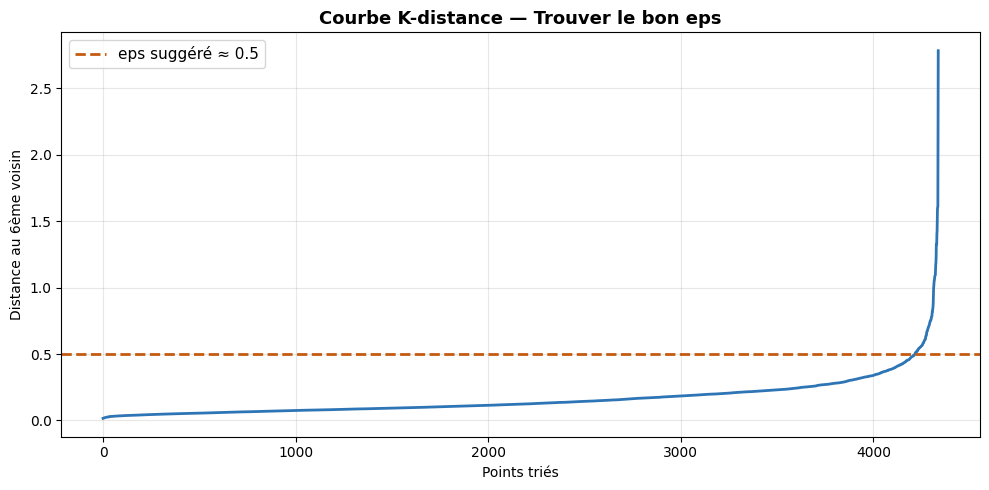

In [62]:
# Règle générale : min_samples = 2 × nombre de dimensions = 2×3 = 6
MIN_SAMPLES = 6

neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors.fit(rfm_scaled)
distances, _ = neighbors.kneighbors(rfm_scaled)

# Trier les distances du 6ème voisin
distances = np.sort(distances[:, MIN_SAMPLES-1])

plt.figure(figsize=(10, 5))
plt.plot(distances, color='#2E75B6', linewidth=2)
plt.title('Courbe K-distance — Trouver le bon eps',
          fontsize=13, fontweight='bold')
plt.xlabel('Points triés')
plt.ylabel(f'Distance au {MIN_SAMPLES}ème voisin')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='#C55A11', linestyle='--',
            linewidth=2, label='eps suggéré ≈ 0.5')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
for eps in [0.3, 0.5, 0.7, 1.0]:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(rfm_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"eps={eps} → {n_clusters} clusters | "
          f"{n_noise} outliers ({n_noise/len(rfm)*100:.1f}%)")

eps=0.3 → 10 clusters | 297 outliers (6.8%)
eps=0.5 → 3 clusters | 64 outliers (1.5%)
eps=0.7 → 1 clusters | 32 outliers (0.7%)
eps=1.0 → 1 clusters | 10 outliers (0.2%)


In [64]:
EPS_OPTIMAL = 0.5

db_final = DBSCAN(eps=EPS_OPTIMAL, min_samples=MIN_SAMPLES)
rfm['DBSCAN_Cluster'] = db_final.fit_predict(rfm_scaled)

n_clusters = len(set(rfm['DBSCAN_Cluster'])) - \
             (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise = (rfm['DBSCAN_Cluster'] == -1).sum()

print(f"DBSCAN entraîné : eps={EPS_OPTIMAL}, min_samples={MIN_SAMPLES}")
print(f"   Clusters trouvés : {n_clusters}")
print(f"   Outliers (bruit) : {n_noise} ({n_noise/len(rfm)*100:.1f}%)")
print()
print(rfm['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN entraîné : eps=0.5, min_samples=6
   Clusters trouvés : 3
   Outliers (bruit) : 64 (1.5%)

DBSCAN_Cluster
-1      64
 0    2788
 1    1484
 2       2
Name: count, dtype: int64


In [65]:
# Profil détaillé
dbscan_profile = rfm.groupby('DBSCAN_Cluster').agg(
    Nb_Clients   = ('CustomerID', 'count'),
    Recency_moy  = ('Recency',    'mean'),
    Freq_moy     = ('Frequency',  'mean'),
    Monetary_moy = ('Monetary',   'mean'),
).round(1)
print("📋 PROFIL DBSCAN (-1 = outliers/bruit)")

print(dbscan_profile.to_string())

📋 PROFIL DBSCAN (-1 = outliers/bruit)
                Nb_Clients  Recency_moy  Freq_moy  Monetary_moy
DBSCAN_Cluster                                                 
-1                      64         54.5      32.3       42805.7
 0                    2788         59.2       5.4        1994.8
 1                    1484        156.9       1.0         354.3
 2                       2          9.5      20.5       30134.9


In [66]:
import joblib

# Sauvegarder les modèles

joblib.dump(db_final,'models/dbscan_model.pkl')

# Sauvegarder dataset enrichi
#rfm.to_csv('data/processed/rfm_clustered.csv', index=False)

print("Tous les fichiers sauvegardés dans Google Drive")

Tous les fichiers sauvegardés dans Google Drive
